# 05 · Gradient-Boosted Tree Models

**Phase 7 (XGBoost / LightGBM) + Phase 10 (deeper error analysis) of the project plan.**

Random Forest set a strong baseline in `04_baseline_models.ipynb`. Gradient-boosted trees (XGBoost, LightGBM) usually push further by fitting residuals sequentially rather than averaging independent trees. We fit a sensible default configuration for each, sketch a leakage-safe (`GroupKFold` on engine id) hyperparameter search you can choose to run, and finish with the same error-analysis toolkit used before — this time on the strongest model so far.


In [1]:
import sys
sys.path.insert(0, "..")

import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
import xgboost as xgb
import lightgbm as lgb

from src import evaluate as ev

PROCESSED_DIR = "../data/processed"
ARTIFACTS_DIR = "../artifacts"
REPORTS_DIR = "../reports"
MODELS_DIR = "../models"
SUBSET = "FD001"

train = pd.read_parquet(f"{PROCESSED_DIR}/train_{SUBSET}_features.parquet")
val = pd.read_parquet(f"{PROCESSED_DIR}/val_{SUBSET}_features.parquet")
manifest = joblib.load(f"{ARTIFACTS_DIR}/scalers/feature_manifest_{SUBSET}.joblib")
feature_cols = manifest["feature_cols"]

X_train, y_train = train[feature_cols], train["RUL"]
X_val, y_val = val[feature_cols], val["RUL"]

leaderboard = pd.read_csv(f"{REPORTS_DIR}/model_leaderboard.csv", index_col=0)
leaderboard


,MAE,RMSE,R2,NASA_score,n
Constant (mean),54.685121,64.940643,-0.002005,1.694377e+07,4010.0
Linear Regression,27.603866,34.314158,0.720242,4.685359e+05,4010.0
Decision Tree,29.383932,41.465260,0.591488,3.457276e+09,4010.0
Random Forest,23.666739,32.988330,0.741442,1.897109e+06,4010.0


## XGBoost — default configuration

A moderate-depth, moderate-learning-rate configuration with early stopping against the validation set, so the number of boosting rounds is chosen automatically rather than guessed.


In [2]:
t0 = time.perf_counter()
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    early_stopping_rounds=50,
    eval_metric="mae",
    n_jobs=-1,
    random_state=42,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_fit_seconds = time.perf_counter() - t0

y_pred_xgb = xgb_model.predict(X_val)
xgb_report = {**ev.regression_report(y_val, y_pred_xgb), "fit_seconds": xgb_fit_seconds, "best_iteration": xgb_model.best_iteration}
xgb_report


{'MAE': 23.06290626525879,
 'RMSE': 31.681935801846826,
 'R2': 0.7615156173706055,
 'NASA_score': 976021.6292256041,
 'n': 4010,
 'fit_seconds': 3.670478500018362,
 'best_iteration': 148}

## Optional — leakage-safe hyperparameter search for XGBoost

`GroupKFold` keeps every engine's rows in a single fold, so cross-validation folds never split an engine across train/validation the way plain `KFold` would. This search is written but **not required** to proceed — it can take a while depending on `n_iter`; lower it for a quick check or raise it if you want a more thorough search. Skip this cell entirely if the default model above is already good enough for your purposes.


In [3]:
param_distributions = {
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [0.1, 1.0, 5.0, 10.0],
}

group_kfold = GroupKFold(n_splits=5)
groups = train["unit_number"].values

search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(n_estimators=300, n_jobs=-1, random_state=42),
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=group_kfold.split(X_train, y_train, groups=groups),
    random_state=42,
    verbose=1,
)
# Uncomment to run (can take several minutes depending on n_iter/hardware):
# search.fit(X_train, y_train)
# print(search.best_params_)


## LightGBM — default configuration

Similar boosting recipe to XGBoost but with leaf-wise tree growth, which often trains faster on tabular data of this size.


In [4]:
t0 = time.perf_counter()
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    max_depth=-1,
    num_leaves=63,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    verbosity=-1,
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)
lgb_fit_seconds = time.perf_counter() - t0

y_pred_lgb = lgb_model.predict(X_val)
lgb_report = {**ev.regression_report(y_val, y_pred_lgb), "fit_seconds": lgb_fit_seconds, "best_iteration": lgb_model.best_iteration_}
lgb_report


C:\Users\BobyDubey\Downloads\Ambika\aircraft-rul-prognostics\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


{'MAE': 23.706452410508703,
 'RMSE': 32.54539810542953,
 'R2': 0.748339103910566,
 'NASA_score': 1790216.325997566,
 'n': 4010,
 'fit_seconds': 1.9120478000259027,
 'best_iteration': 108}

## Updated leaderboard

Appending XGBoost and LightGBM to the running comparison from `04_baseline_models.ipynb`.


In [5]:
new_rows = ev.metrics_table({"XGBoost": xgb_report, "LightGBM": lgb_report})
leaderboard = pd.concat([leaderboard, new_rows[~new_rows.index.isin(leaderboard.index)]])
# refresh rows for models re-run in this notebook
leaderboard.loc[new_rows.index, new_rows.columns] = new_rows
leaderboard.to_csv(f"{REPORTS_DIR}/model_leaderboard.csv")
leaderboard.sort_values("MAE")


,MAE,RMSE,R2,NASA_score,n
XGBoost,23.062906,31.681936,0.761516,9.760216e+05,4010.0
Random Forest,23.666739,32.988330,0.741442,1.897109e+06,4010.0
LightGBM,23.706452,32.545398,0.748339,1.790216e+06,4010.0
Linear Regression,27.603866,34.314158,0.720242,4.685359e+05,4010.0
Decision Tree,29.383932,41.465260,0.591488,3.457276e+09,4010.0
Constant (mean),54.685121,64.940643,-0.002005,1.694377e+07,4010.0


## Choosing the best model so far

Picking whichever model has the lowest validation MAE for the deeper error analysis below and for downstream use in `07_explainability.ipynb` / `08_failure_probability.ipynb`. Re-run this cell after any hyperparameter tuning above.


In [6]:
candidates = {"Random Forest": None, "XGBoost": xgb_model, "LightGBM": lgb_model}
predictions = {"XGBoost": y_pred_xgb, "LightGBM": y_pred_lgb}

best_name = leaderboard.loc[["XGBoost", "LightGBM"]]["MAE"].idxmin()
best_model = candidates[best_name]
y_pred_best = predictions[best_name]
print(f"Best tree model on validation MAE: {best_name}")


Best tree model on validation MAE: XGBoost


## Phase 10 — Deeper error analysis on the best tree model


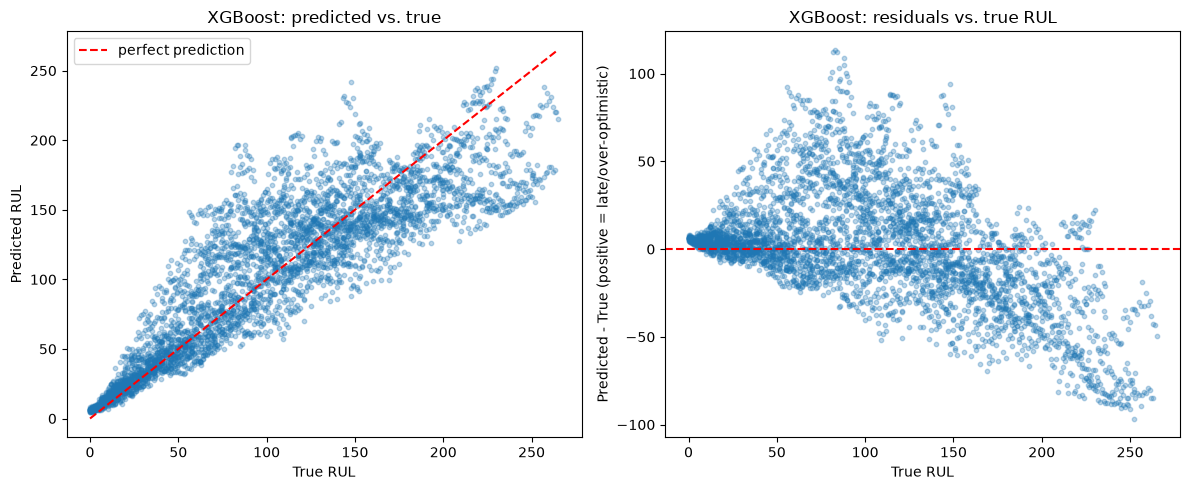

,n,MAE,RMSE,NASA_score
bucket,,,,
RUL <= 20,420,5.323335,6.529105,367.022289
20 < RUL <= 50,600,11.246091,17.249842,8805.525497
50 < RUL <= 100,1000,27.380180,36.225425,734423.925373
RUL > 100,1990,28.200312,35.559404,232425.156067


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_val, y_pred_best, alpha=0.3, s=10)
lims = [0, max(y_val.max(), y_pred_best.max())]
axes[0].plot(lims, lims, "r--", label="perfect prediction")
axes[0].set_xlabel("True RUL")
axes[0].set_ylabel("Predicted RUL")
axes[0].set_title(f"{best_name}: predicted vs. true")
axes[0].legend()

residuals = y_pred_best - y_val
axes[1].scatter(y_val, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("True RUL")
axes[1].set_ylabel("Predicted - True (positive = late/over-optimistic)")
axes[1].set_title(f"{best_name}: residuals vs. true RUL")

plt.tight_layout()
plt.show()

ev.evaluate_by_rul_bin(y_val, y_pred_best)


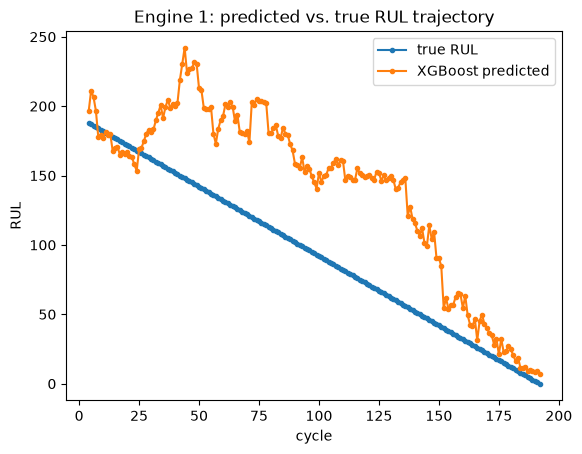

In [8]:
# Example single-engine trajectory: predicted vs. true RUL over the engine's observed cycles
example_engine = val["unit_number"].iloc[0]
mask = val["unit_number"] == example_engine
g = val[mask]

plt.plot(g["cycle"], g["RUL"], label="true RUL", marker="o", markersize=3)
plt.plot(g["cycle"], y_pred_best[mask.values], label=f"{best_name} predicted", marker="o", markersize=3)
plt.xlabel("cycle")
plt.ylabel("RUL")
plt.title(f"Engine {example_engine}: predicted vs. true RUL trajectory")
plt.legend()
plt.show()


## Save the best model


In [9]:
joblib.dump(best_model, f"{MODELS_DIR}/best_model_{SUBSET}.joblib")
joblib.dump({"model_name": best_name, "feature_cols": feature_cols, "target": "RUL"}, f"{MODELS_DIR}/best_model_{SUBSET}_meta.joblib")
print(f"saved {best_name} as the running best model")


saved XGBoost as the running best model


## Summary

- Fit default-configuration XGBoost and LightGBM with early stopping against the validation set; both compared against Random Forest on the shared leaderboard (`reports/model_leaderboard.csv`).
- Provided (but did not run) a `GroupKFold`-based `RandomizedSearchCV` for XGBoost — uncomment and run it if you want to push accuracy further; it respects the same engine-grouping rule as the train/validation split.
- Error analysis (predicted-vs-true, residuals, per-RUL-bucket metrics, one example engine trajectory) on the strongest model, to see *where* it's weakest rather than just a single aggregate number.
- Persisted the best model + metadata to `models/` for reuse in `07_explainability.ipynb` and `08_failure_probability.ipynb`.

**Next:** `06_lstm_gru.ipynb` — sequence models (LSTM, GRU) that learn temporal patterns directly from raw sensor sequences instead of hand-engineered lag/rolling features.
